In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from IPython.display import display
print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
url = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/air-passengers/AirPassengers.csv"
df = pd.read_csv(url)

In [6]:
df = pd.read_csv(url)
print("Dataset loaded successfully!")
display(df)

Dataset loaded successfully!


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [7]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [8]:
print("Last 5 rows:")
display(df.tail())


Last 5 rows:


,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [9]:
print("Shape of dataset:")
print(df.shape)

Shape of dataset:
(144, 2)


In [10]:
print("Column names:")
print(df.columns)

Column names:
Index(['Month', '#Passengers'], dtype='object')


In [13]:
print("Data types:")
print(df.dtypes)
df["Month"] = pd.to_datetime(df["Month"])

Data types:
Month          datetime64[ns]
#Passengers             int64
dtype: object


In [14]:
print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Month          datetime64[ns]
#Passengers             int64
dtype: object


In [15]:
print("Dataset after converting Month to datetime:")
display(df.head())

Dataset after converting Month to datetime:


,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [16]:
df.set_index("Month", inplace=True)

In [17]:
print("Dataset after setting Month as index:")
display(df.head())

Dataset after setting Month as index:


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [18]:
print("Index:")
print(df.index)

Index:
DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)


In [19]:
print("DataFrame information:")
print(df.info())

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


In [20]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
#Passengers    0
dtype: int64


In [21]:
print("Statistical summary:")
display(df.describe())

Statistical summary:


,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


Text(0.5, 1.0, 'Monthly International Airline Passengers')

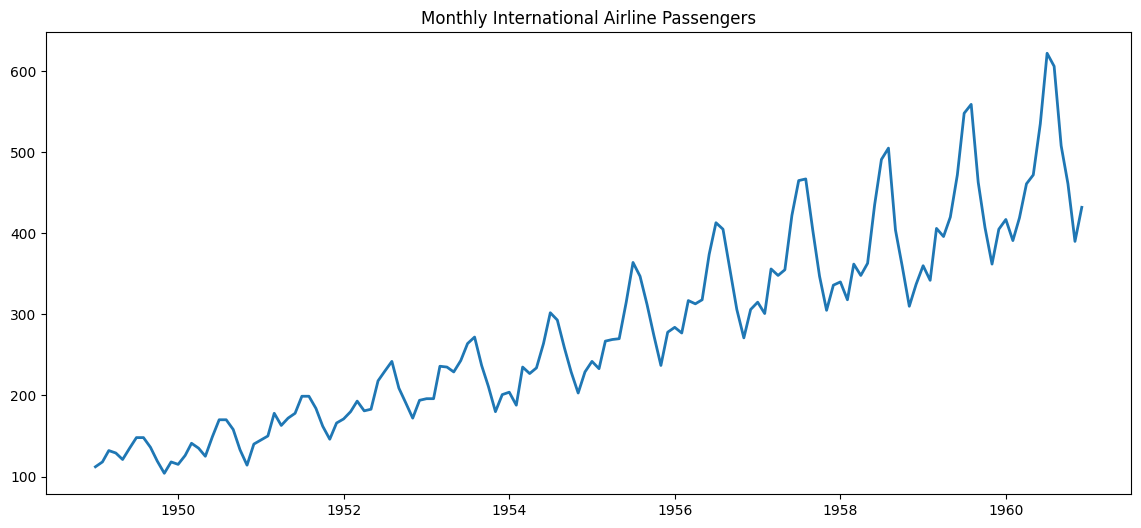

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(
    df.index,
    df["#Passengers"],
    linewidth=2
)
plt.title("Monthly International Airline Passengers")

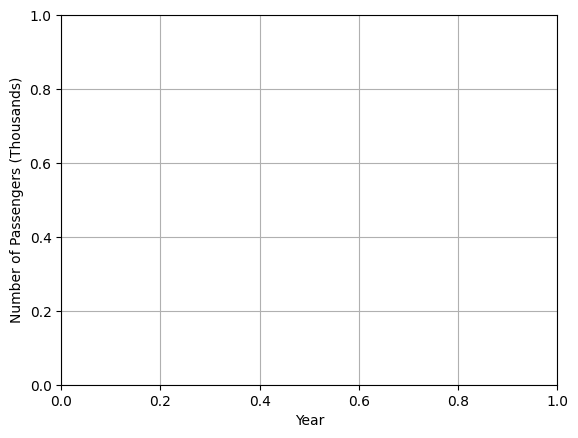

In [23]:
plt.xlabel("Year")
plt.ylabel("Number of Passengers (Thousands)")
plt.grid(True)
plt.show()

Seasonal period: 12
Reason: The data is monthly and one year contains 12 months.
Decomposition completed successfully!


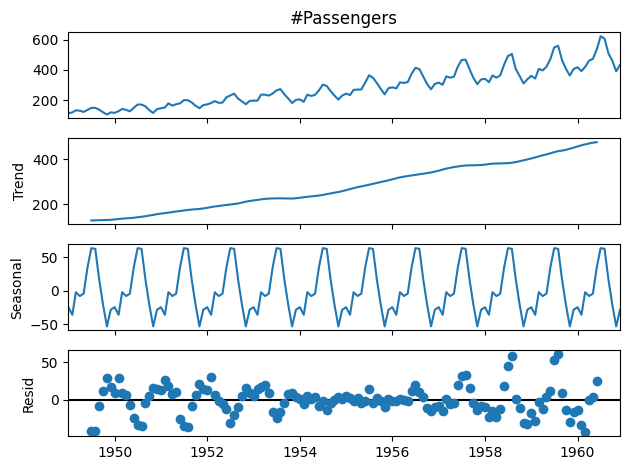

In [24]:
seasonal_period = 12
print("Seasonal period:", seasonal_period)
print("Reason: The data is monthly and one year contains 12 months.")
decomposition = seasonal_decompose(
    df["#Passengers"],
    model="additive",
    period=12
)
print("Decomposition completed successfully!")
decomposition.plot()
plt.show()

In [25]:
observed = decomposition.observed
print("Observed component:")
display(observed.head(10))
trend = decomposition.trend
print("Trend component:")
display(trend.head(15))

Observed component:


Month
1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
1949-06-01    135.0
1949-07-01    148.0
1949-08-01    148.0
1949-09-01    136.0
1949-10-01    119.0
Name: #Passengers, dtype: float64

Trend component:


Month
1949-01-01           NaN
1949-02-01           NaN
1949-03-01           NaN
1949-04-01           NaN
1949-05-01           NaN
1949-06-01           NaN
1949-07-01    126.791667
1949-08-01    127.250000
1949-09-01    127.958333
1949-10-01    128.583333
1949-11-01    129.000000
1949-12-01    129.750000
1950-01-01    131.250000
1950-02-01    133.083333
1950-03-01    134.916667
Name: trend, dtype: float64

In [26]:
seasonal = decomposition.seasonal
print("Seasonal component:")
display(seasonal.head(15))

Seasonal component:


Month
1949-01-01   -24.748737
1949-02-01   -36.188131
1949-03-01    -2.241162
1949-04-01    -8.036616
1949-05-01    -4.506313
1949-06-01    35.402778
1949-07-01    63.830808
1949-08-01    62.823232
1949-09-01    16.520202
1949-10-01   -20.642677
1949-11-01   -53.593434
1949-12-01   -28.619949
1950-01-01   -24.748737
1950-02-01   -36.188131
1950-03-01    -2.241162
Name: seasonal, dtype: float64

Residual component:


Month
1949-01-01          NaN
1949-02-01          NaN
1949-03-01          NaN
1949-04-01          NaN
1949-05-01          NaN
1949-06-01          NaN
1949-07-01   -42.622475
1949-08-01   -42.073232
1949-09-01    -8.478535
1949-10-01    11.059343
1949-11-01    28.593434
1949-12-01    16.869949
1950-01-01     8.498737
1950-02-01    29.104798
1950-03-01     8.324495
Name: resid, dtype: float64

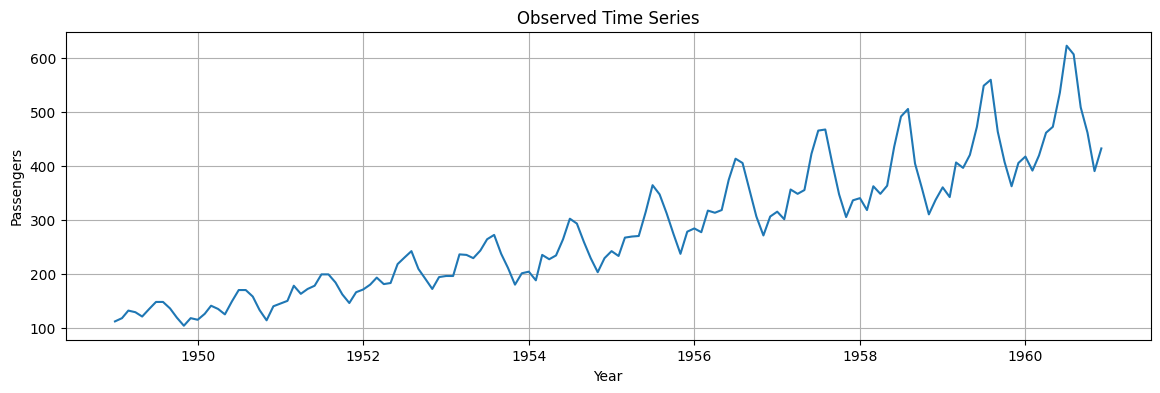

In [27]:
residual = decomposition.resid
print("Residual component:")
display(residual.head(15))
plt.figure(figsize=(14, 4))
plt.plot(observed)
plt.title("Observed Time Series")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()